In [22]:
#filtering the downloaded ids
import os
import pandas as pd

# ======== User Inputs ========
image_folder = "/home/fahimul/Documents/Research/Proj_worldDataset/datasets/osv5m_sat/train"
csv_file = "/home/fahimul/Documents/Research/Proj_worldDataset/datasets/osv5m/train.csv"
output_csv = "/home/fahimul/Documents/Research/Proj_worldDataset/csv/subset_train.csv"
image_id_column = "id"  # name of the column in your CSV containing image IDs
# ==============================

# Step 1: Recursively get all image IDs from the folder (without extensions)
folder_image_ids = set()
for root, _, files in os.walk(image_folder):
    for fname in files:
        if fname.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp', '.tiff', '.gif')):
            folder_image_ids.add(os.path.splitext(fname)[0])

# print(list(folder_image_ids)[0:5])

# Step 2: Read the CSV file
df = pd.read_csv(csv_file)

# Step 3: Filter rows where image_id is in the folder
subset_df = df[df[image_id_column].astype(str).isin(folder_image_ids)]

# Step 4: Save the filtered subset
subset_df.to_csv(output_csv, index=False)

print(f"✅ Subset saved to: {output_csv}")
print(f"Matched {len(subset_df)} out of {len(df)} rows.")


/tmp/ipykernel_2069361/3946105383.py:22: DtypeWarning: Columns (11,27) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(csv_file)


✅ Subset saved to: /home/fahimul/Documents/Research/Proj_worldDataset/csv/subset_train.csv
Matched 307280 out of 4894684 rows.


In [ ]:
# copying ground image and saving ground image path
# a0==test, a1==train

import os
import shutil
import pandas as pd

# ======== User Inputs ========
csv_file = "csv/subset_train.csv"
image_id_column = "id"  # name of the column containing image IDs
source_parent = "/home/fahimul/Documents/Research/Proj_worldDataset/datasets/osv5m/images/test"
dest_parent = "/home/fahimul/Documents/Research/Proj_worldDataset/datasets/osv5m_gnd/a0"
output_csv = "/home/fahimul/Documents/Research/Proj_worldDataset/csv/subset_train_v1.csv"
# ==============================

# Step 1: Read the CSV
df = pd.read_csv(csv_file)

# Step 2: Build a mapping of all images in source folders
image_map = {}
for root, _, files in os.walk(source_parent):
    for fname in files:
        name, ext = os.path.splitext(fname)
        if ext.lower() in ('.jpg', '.jpeg', '.png', '.bmp', '.tiff', '.gif'):
            image_map[name] = os.path.join(root, fname)

# Step 3: Create destination folders as needed and copy images
new_paths = []
for img_id in df[image_id_column].astype(str):
    if img_id in image_map:
        src_path = image_map[img_id]

        # Find relative path of the image (preserving folder structure)
        rel_path = os.path.relpath(src_path, source_parent)
        dest_path = os.path.join(dest_parent, rel_path)

        # Create destination folder if it doesn't exist
        os.makedirs(os.path.dirname(dest_path), exist_ok=True)

        # Copy the image
        shutil.copy2(src_path, dest_path)

        new_paths.append(dest_path)
    else:
        new_paths.append(None)

# Step 4: Add new column with new paths
df["gnd_image_path"] = new_paths

# Step 5: Save updated CSV
df.to_csv(output_csv, index=False)

print(f"✅ Images copied and CSV updated: {output_csv}")
print(f"Total copied: {sum(x is not None for x in new_paths)} / {len(df)}")


✅ Images copied and CSV updated: /home/fahimul/Documents/Research/Proj_worldDataset/csv/subset_train_v1.csv
Total copied: 307280 / 307280


In [18]:
# saving image path
# a0==test, a1==train

import os
import pandas as pd


# ======== User Inputs ========
csv_file = "/home/fahimul/Documents/Research/Proj_worldDataset/csv/subset_train_v1.csv"
image_id_column = "id"  # column in CSV containing image IDs
source_parent = "/home/fahimul/Documents/Research/Proj_worldDataset/datasets/osv5m_sat/a1"  # parent folder containing all images (in subfolders)
output_csv = "csv/subset_train_v2.csv"
# ==============================

# Step 1: Read the CSV
df = pd.read_csv(csv_file)

# Step 2: Build a mapping of all images (ID → full path)
image_map = {}
for root, _, files in os.walk(source_parent):
    for fname in files:
        name, ext = os.path.splitext(fname)
        if ext.lower() in ('.jpg', '.jpeg', '.png', '.bmp', '.tiff', '.gif'):
            image_map[name] = os.path.join(root, fname)

# Step 3: Match each image_id in the CSV to its full path
paths = []
for img_id in df[image_id_column].astype(str):
    path = image_map.get(img_id, None)
    paths.append(path)

# Step 4: Add new column and save updated CSV
df["sat_image_path"] = paths
df.to_csv(output_csv, index=False)

print(f"✅ Updated CSV saved to: {output_csv}")
print(f"Matched {sum(p is not None for p in paths)} / {len(df)} images.")



✅ Updated CSV saved to: csv/subset_train_v2.csv
Matched 307280 / 307280 images.


In [19]:
#combining subset_train_v2 and subset_test_v2 csv

import pandas as pd

# ======== User Inputs ========
csv1 = "/home/fahimul/Documents/Research/Proj_worldDataset/csv/subset_train_v2.csv"
csv2 = "/home/fahimul/Documents/Research/Proj_worldDataset/csv/subset_test_v2.csv"
output_csv = "/home/fahimul/Documents/Research/Proj_worldDataset/csv/subset_all.csv"
# ==============================

# Step 1: Read both CSV files
df1 = pd.read_csv(csv1)
df2 = pd.read_csv(csv2)

# Step 2: Combine (stack) them
combined_df = pd.concat([df1, df2], ignore_index=True)

# Step 3: Save the combined file
combined_df.to_csv(output_csv, index=False)

print(f"✅ Combined CSV saved to: {output_csv}")
print(f"Total rows: {len(combined_df)} (from {len(df1)} + {len(df2)})")


✅ Combined CSV saved to: /home/fahimul/Documents/Research/Proj_worldDataset/csv/subset_all.csv
Total rows: 500000 (from 307280 + 192720)


In [ ]:
# cleaning
import pandas as pd
csv = "/home/fahimul/Documents/Research/Proj_worldDataset/csv/subset_all.csv"

df = pd.read_csv(csv)
drop_col = ['thumb_original_url', 'sequence', 'captured_at', 'cell', 'land_cover', 'land_cover', 'road_index', 'drive_side',
       'climate', 'soil', 'dist_sea', 'creator_username', 'creator_id', 'quadtree_10_5000', 'quadtree_10_25000',
       'quadtree_10_1000', 'quadtree_10_50000', 'quadtree_10_12500',
       'quadtree_10_500', 'quadtree_10_2500']
df_1 = df.drop(columns=drop_col)

df_1.to_csv("csv/subset_all_final.csv", index=False)

In [9]:
#seperating country 

import pandas as pd

# country_code = "CN"
# ======== User Inputs ========
csv_file = "csv/subset_all_final.csv"
output_br = "csv/country_wise/all_es.csv"
output_main = "csv/all.csv"
# ==============================

# Step 1: Read CSV
df = pd.read_csv(csv_file)

# Step 2: Separate rows where country == 'BR'
AU_NZ_rows = df[df["country"].isin(["ES"])]
# remaining_rows = df[~df["country"].isin(["AU", "NZ"])]

# # Step 3: Save both
AU_NZ_rows.to_csv(output_br, index=False)
# remaining_rows.to_csv(output_main, index=False)

print(f"✅ Saved {len(AU_NZ_rows)} 'AU_NZ' rows to: {output_br}")
# print(f"✅ Saved remaining {len(remaining_rows)} rows to: {output_main}")


✅ Saved 2268 'AU_NZ' rows to: csv/country_wise/all_es.csv


In [10]:
# train/test split

import pandas as pd

version = "es"
# ======== User Inputs ========
csv_file = f"csv/country_wise/all_{version}.csv"
train_csv = f"csv/country_wise/train_{version}.csv"
test_csv = f"csv/country_wise/test_{version}.csv"
# train_csv = f"/home/fahimul/Documents/Research/Proj_worldDataset/csv/train_{version}.csv"
# test_csv = f"/home/fahimul/Documents/Research/Proj_worldDataset/csv/test_{version}.csv"
split_ratio = 0.9 
# ==============================

# Step 1: Read CSV
df = pd.read_csv(csv_file)

# Step 2: Shuffle and split
df_shuffled = df.sample(frac=1, random_state=42).reset_index(drop=True)  # shuffle rows
split_index = int(len(df_shuffled) * split_ratio)

train_df = df_shuffled[:split_index]
test_df = df_shuffled[split_index:]

# Step 3: Save both parts
train_df.to_csv(train_csv, index=False)
test_df.to_csv(test_csv, index=False)

print(f"✅ Split complete!")
print(f"Training set: {len(train_df)} rows")
print(f"Test set: {len(test_df)} rows")


✅ Split complete!
Training set: 2041 rows
Test set: 227 rows


unique_country
BR    144116
AR     45082
CO     27750
CL     24997
US     21923
BO     18839
PE     16623
RU     13783
EC     12524
AU     10146
CA      8768
GH      8405
CR      6759
IN      6011
UY      5721
PY      4981
PA      4598
MX      4327
CN      4025
KZ      3548
TR      3258
CD      3005
ZA      2714
SL      2582
NO      2550
NZ      2513
TH      2469
ID      2395
ZM      2304
ES      2268
Name: count, dtype: int64


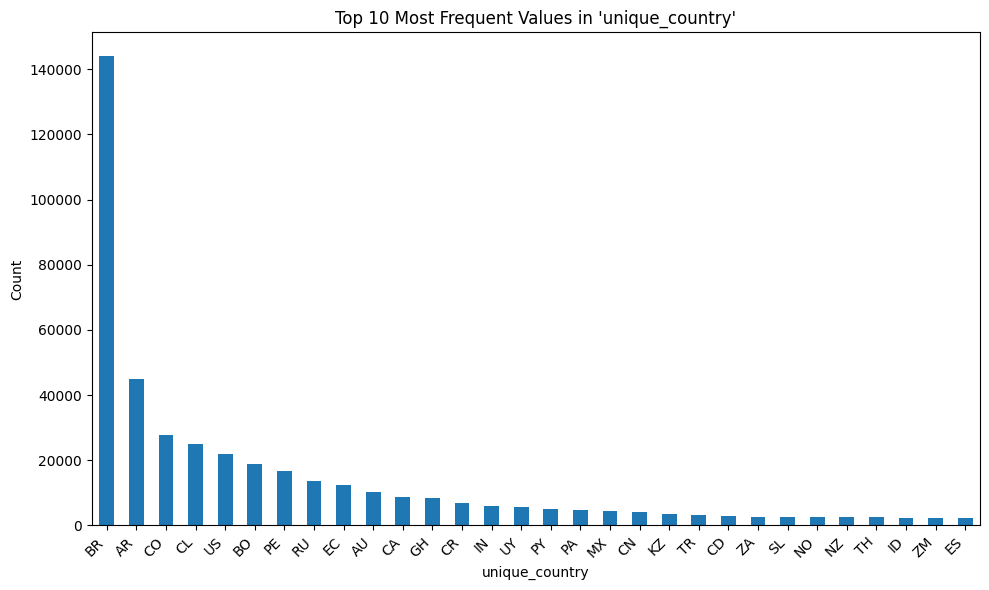

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

csv_file = "/home/fahimul/Documents/Research/Proj_worldDataset/csv/subset_all_final.csv"

# ======== Example Setup ========
# Read your CSV (or create DataFrame)
df = pd.read_csv(csv_file)
column_name = "unique_country"  # change this to your target column
# ================================


# Step 2: Count unique values and get top 10
value_counts = df[column_name].value_counts().head(30)
print(value_counts)
# Step 3: Plot a bar chart
plt.figure(figsize=(10, 6))
value_counts.plot(kind='bar')
plt.title(f"Top 10 Most Frequent Values in '{column_name}'")
plt.xlabel(column_name)
plt.ylabel("Count")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## Continent pi chart

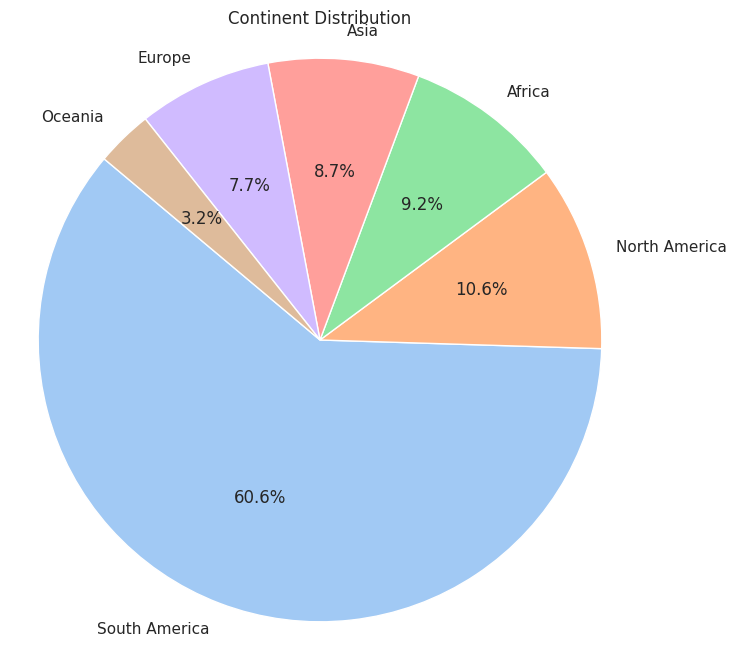

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import pycountry
import pycountry_convert as pc
import seaborn as sns

# ---------------------------
# 1. Load CSV files
# ---------------------------
# csv1 = pd.read_csv("file1.csv")
# csv2 = pd.read_csv("file2.csv")

# ---------------------------
# 2. Join the CSV files
# (change the column name if needed) unique_country
# ---------------------------
# df = pd.merge(csv1, csv2, on="country_code", how="inner")

# # If you just want to stack rows instead:
# df = pd.concat([csv1, csv2], ignore_index=True)


csv_file = "/home/fahimul/Documents/Research/Proj_worldDataset/csv/subset_all_final.csv"

# ======== Example Setup ========
# Read your CSV (or create DataFrame)
df = pd.read_csv(csv_file)

# -----------------------------
# Convert country code → continent
# -----------------------------
def get_continent(code):
    try:
        continent_code = pc.country_alpha2_to_continent_code(code)
        continent_map = {
            "AF": "Africa",
            "AS": "Asia",
            "EU": "Europe",
            "NA": "North America",
            "SA": "South America",
            "OC": "Oceania",
            "AN": "Antarctica"
        }
        return continent_map.get(continent_code)
    except:
        return None

df["continent"] = df["unique_country"].apply(get_continent)

# -----------------------------
# Remove Unknown / None values
# -----------------------------
df = df.dropna(subset=["continent"])

# -----------------------------
# Continent distribution
# -----------------------------
continent_counts = df["continent"].value_counts()

# -----------------------------
# Seaborn styling
# -----------------------------
sns.set_theme(style="whitegrid")
colors = sns.color_palette("pastel", len(continent_counts))

# -----------------------------
# Pie Chart
# -----------------------------
plt.figure(figsize=(8,8))

plt.pie(
    continent_counts,
    labels=continent_counts.index,
    autopct="%1.1f%%",
    startangle=140,
    colors=colors
)

plt.title("Continent Distribution")
plt.axis("equal")

plt.show()

(304747, 15)


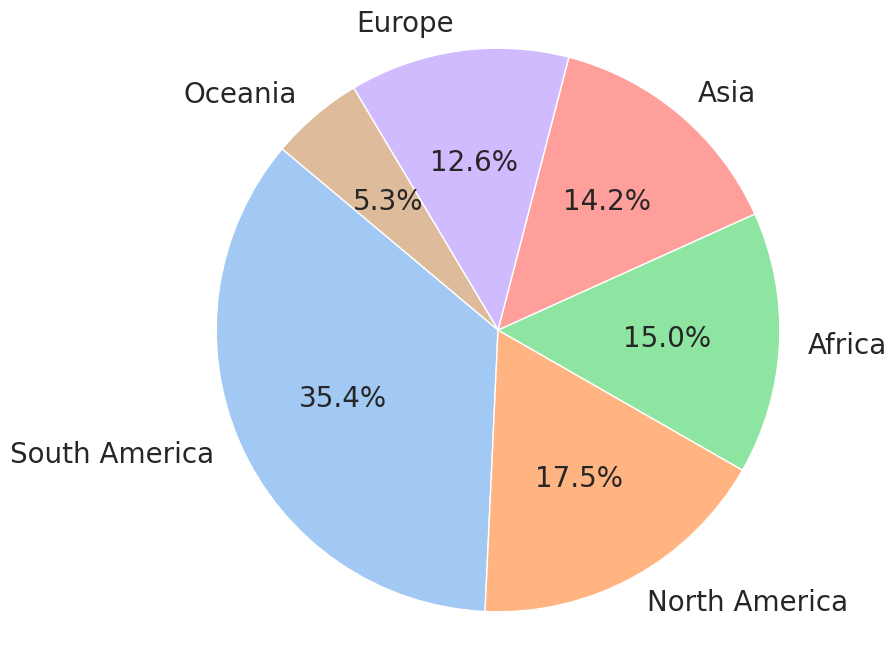

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pycountry_convert as pc

# ---------------------------
# 1. Load CSV files
# ---------------------------
# csv1 = pd.read_csv("file1.csv")
# csv2 = pd.read_csv("file2.csv")

# ---------------------------
# 2. Join the CSV files
# (change the column name if needed) unique_country
# ---------------------------
# df = pd.merge(csv1, csv2, on="country_code", how="inner")

# # If you just want to stack rows instead:
# df = pd.concat([csv1, csv2], ignore_index=True)


csv_file = "/home/fahimul/Documents/Research/Proj_worldDataset/csv/subset_all_final.csv"

# ======== Example Setup ========
# Read your CSV (or create DataFrame)
df = pd.read_csv(csv_file) #unique_country

# Remove Brazil (country code BR)
# -----------------------------
# df = df[df["unique_country"] != "BR"]
# df = df[df["unique_country"] != "AR"]


# -----------------------------
# Downsample specific countries
# -----------------------------
def reduce_country(df, code, remove_percent):
    country_df = df[df["unique_country"] == code]
    keep_fraction = 1 - remove_percent
    kept = country_df.sample(frac=keep_fraction, random_state=42)
    df_other = df[df["unique_country"] != code]
    return pd.concat([df_other, kept])

# remove 80% of Brazil
df = reduce_country(df, "BR", 0.90)

# remove 40% of Argentina
df = reduce_country(df, "AR", 0.90)

# remove 40% of Columbia
df = reduce_country(df, "CO", 0.90)

print(df.shape)

# -----------------------------
# Convert country code → continent
# -----------------------------
def get_continent(code):
    try:
        continent_code = pc.country_alpha2_to_continent_code(code)
        continent_map = {
            "AF": "Africa",
            "AS": "Asia",
            "EU": "Europe",
            "NA": "North America",
            "SA": "South America",
            "OC": "Oceania",
            "AN": "Antarctica"
        }
        return continent_map.get(continent_code)
    except:
        return None

df["continent"] = df["unique_country"].apply(get_continent)

# -----------------------------
# Remove Unknown continents
# -----------------------------
df = df.dropna(subset=["continent"])

# -----------------------------
# Continent distribution
# -----------------------------
continent_counts = df["continent"].value_counts()

# -----------------------------
# Seaborn style
# -----------------------------
sns.set_theme(style="whitegrid")
colors = sns.color_palette("pastel", len(continent_counts))

# -----------------------------
# Pie chart
# -----------------------------
plt.figure(figsize=(8,8))

# plt.pie(
#     continent_counts,
#     labels=continent_counts.index,
#     autopct="%1.1f%%",
#     startangle=140,
#     colors=colors
# )

wedges, texts, autotexts = plt.pie(
    continent_counts,
    labels=continent_counts.index,
    autopct="%1.1f%%",
    startangle=140,
    colors=colors
)

for text in texts:
    text.set_fontsize(20)

for autotext in autotexts:
    autotext.set_fontsize(20)


# plt.title("Continent Distribution")
plt.axis("equal")

plt.show()

## Coastal vs Inland analysis

/home/fahimul/.conda/envs/CVGL_v3/lib/python3.9/site-packages/shapely/measurement.py:72: RuntimeWarning: invalid value encountered in distance
  return lib.distance(a, b, **kwargs)


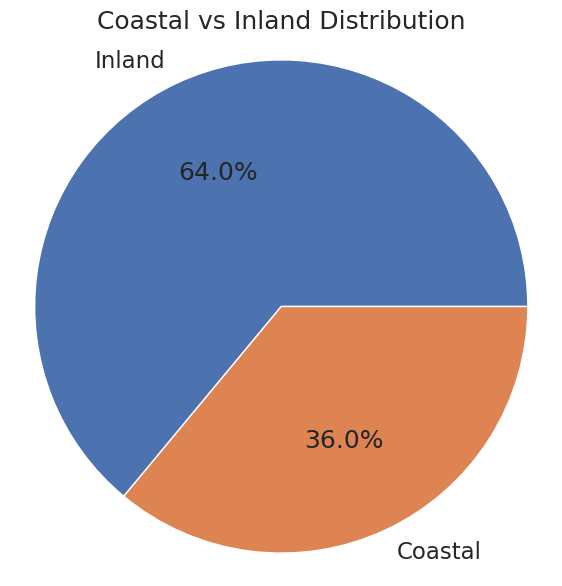

In [2]:
import pandas as pd
import geopandas as gpd
import seaborn as sns
import matplotlib.pyplot as plt
from shapely.geometry import Point

# -----------------------------
# Load dataset
# -----------------------------

csv_file = "/home/fahimul/Documents/Research/Proj_worldDataset/csv/subset_all_final.csv"

# ======== Example Setup ========
# Read your CSV (or create DataFrame)
df = pd.read_csv(csv_file) #unique_country


# -----------------------------
# Downsample specific countries
# -----------------------------
def reduce_country(df, code, remove_percent):
    country_df = df[df["unique_country"] == code]
    keep_fraction = 1 - remove_percent
    kept = country_df.sample(frac=keep_fraction, random_state=42)
    df_other = df[df["unique_country"] != code]
    return pd.concat([df_other, kept])

# remove 80% of Brazil
df = reduce_country(df, "BR", 0.90)

# remove 40% of Argentina
df = reduce_country(df, "AR", 0.90)

# remove 40% of Columbia
df = reduce_country(df, "CO", 0.90)

# -----------------------------
# -----------------------------

# dataset must contain latitude & longitude
gdf = gpd.GeoDataFrame(
    df,
    geometry=gpd.points_from_xy(df.longitude, df.latitude),
    crs="EPSG:4326"
)

# -----------------------------
# Load coastline shapefile
# -----------------------------
coastline = gpd.read_file("metadata/ne_10m_coastline/ne_10m_coastline.shp")

# Convert projection for distance calculation
gdf = gdf.to_crs(epsg=3857)
coastline = coastline.to_crs(epsg=3857)

# -----------------------------
# Compute distance to coastline
# -----------------------------
gdf["distance_to_coast_km"] = gdf.geometry.apply(
    lambda x: coastline.distance(x).min() / 1000
)

# -----------------------------
# Coastal vs Inland
# -----------------------------
threshold = 50  # km
gdf["location_type"] = gdf["distance_to_coast_km"].apply(
    lambda x: "Coastal" if x <= threshold else "Inland"
)

# -----------------------------
# Distribution
# -----------------------------
counts = gdf["location_type"].value_counts()

# -----------------------------
# Plot
# -----------------------------
sns.set_theme(style="whitegrid", font_scale=1.5)

plt.figure(figsize=(7,7))
plt.pie(counts, labels=counts.index, autopct="%1.1f%%")
plt.title("Coastal vs Inland Distribution")
plt.axis("equal")

plt.show()

## Rural vs Urban distribution

In [ ]:
import pandas as pd
import osmnx as ox
import seaborn as sns
import matplotlib.pyplot as plt


# -----------------------------
# Load dataset
# -----------------------------

csv_file = "/home/fahimul/Documents/Research/Proj_worldDataset/csv/subset_all_final.csv"

# ======== Example Setup ========
# Read your CSV (or create DataFrame)
df = pd.read_csv(csv_file) #unique_country


# -----------------------------
# Downsample specific countries
# -----------------------------
def reduce_country(df, code, remove_percent):
    country_df = df[df["unique_country"] == code]
    keep_fraction = 1 - remove_percent
    kept = country_df.sample(frac=keep_fraction, random_state=42)
    df_other = df[df["unique_country"] != code]
    return pd.concat([df_other, kept])

# remove 80% of Brazil
df = reduce_country(df, "BR", 0.90)

# remove 40% of Argentina
df = reduce_country(df, "AR", 0.90)

# remove 40% of Columbia
df = reduce_country(df, "CO", 0.90)

# -----------------------------
# -----------------------------

def classify_area(lat, lon):

    try:
        tags = {"landuse": True}
        gdf = ox.features_from_point((lat, lon), tags=tags, dist=1000)

        urban_tags = ["residential", "commercial", "industrial"]

        if any(gdf["landuse"].isin(urban_tags)):
            return "Urban"
        else:
            return "Rural"

    except:
        return "Unknown"


df["area_type"] = df.apply(
    lambda row: classify_area(row["latitude"], row["longitude"]),
    axis=1
)

# remove unknown
df = df[df["area_type"] != "Unknown"]

counts = df["area_type"].value_counts()

# plot
sns.set_theme(style="whitegrid", font_scale=1.5)

plt.figure(figsize=(7,7))

plt.pie(
    counts,
    labels=counts.index,
    autopct="%1.1f%%"
)

plt.title("Urban vs Rural Distribution")
plt.axis("equal")

plt.show()

/home/fahimul/.conda/envs/CVGL_v3/lib/python3.9/site-packages/osmnx/features.py:727: FutureWarning: <class 'geopandas.array.GeometryArray'>._reduce will require a `keepdims` parameter in the future
  gdf = gdf[geom_filter & tags_filter].dropna(axis="columns", how="all")
/home/fahimul/.conda/envs/CVGL_v3/lib/python3.9/site-packages/osmnx/features.py:727: FutureWarning: <class 'geopandas.array.GeometryArray'>._reduce will require a `keepdims` parameter in the future
  gdf = gdf[geom_filter & tags_filter].dropna(axis="columns", how="all")
/home/fahimul/.conda/envs/CVGL_v3/lib/python3.9/site-packages/osmnx/features.py:727: FutureWarning: <class 'geopandas.array.GeometryArray'>._reduce will require a `keepdims` parameter in the future
  gdf = gdf[geom_filter & tags_filter].dropna(axis="columns", how="all")
/home/fahimul/.conda/envs/CVGL_v3/lib/python3.9/site-packages/osmnx/features.py:727: FutureWarning: <class 'geopandas.array.GeometryArray'>._reduce will require a `keepdims` parameter in 